# IT362 · Phase 2 · Part 3
## Secondary Data — Processing, Cleaning & Descriptive Statistics


**Research question (Phase 1):** In Riyadh, how do neighborhood and property type relate to average residential rental prices?

**What this notebook does**
1. Documents the secondary data source, scope and limitations.
2. Inspects the raw file, then cleans and prepares it (each step: *what / why / how*).
3. Computes descriptive statistics and distribution plots.



### 0. Secondary data

| Item | Detail |
|---|---|
| Dataset | **Aqar.fm Saudi Real Estate Listings** by *afaskar* (Hugging Face) |
| URL | https://huggingface.co/datasets/afaskar/Aqar.fm-Saudi-Real-Estate-Listings |
| File used | `aqar_fm_listings_rental_cleaned.csv` (kept exactly as downloaded) |
| Original platform | Aqar (sa.aqar.fm) — public listings scraped by the dataset author |
| License | **CC BY 4.0** (attribution required) |
| Date of the data | Collected **30 Dec 2025** according to the dataset card; listings in the file were created between Feb and Dec 2025 |
| Scope used here | Riyadh **residential** rentals: apartments, floors and villas |



In [1]:
import sys, subprocess
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "arabic-reshaper", "python-bidi"])

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"   # contains Arabic glyphs
os.makedirs("figures", exist_ok=True)

DATA_PATH = "aqar_fm_listings_rental_cleaned.csv"   # put the downloaded file next to this notebook

def ar(text):
    # Arabic text needs reshaping + right-to-left ordering to display correctly in matplotlib
    return get_display(arabic_reshaper.reshape(str(text)))

### 1. Load the data
The original file stays untouched in `df_raw`; all cleaning is done on a copy.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print("Rows, columns:", df_raw.shape)
df_raw[["id", "price", "area_sqm", "num_bedrooms", "num_bathrooms", "city", "district", "category_en"]].head()

Rows, columns: (1344, 79)


,id,price,area_sqm,num_bedrooms,num_bathrooms,city,district,category_en
0,6516181,105000.0,102.0,2.0,NaN,الرياض,حي العليا,Big flat for rent
1,6479084,55000.0,50.0,1.0,1.0,الرياض,حي العليا,Apartment for rent
2,6519016,85000.0,96.0,1.0,NaN,الرياض,حي الملك فهد,Office for rent
3,6503363,1500000.0,10000.0,NaN,NaN,جده,حي الزمرد,Land for rent
4,6462507,16000.0,80.0,2.0,NaN,الرياض,حي بدر,Apartment for rent


### 2. Initial inspection of the raw data
We check size, listing types, cities, property categories, missing values and duplicates before cleaning.

In [4]:
print("Listing type flags -> is_rental:", df_raw["is_rental"].value_counts().to_dict(),
      "| is_daily_rental:", df_raw["is_daily_rental"].value_counts().to_dict())
print("\nTop cities:"); print(df_raw["city"].value_counts().head(6).to_string())
print("\nProperty categories (all cities):"); print(df_raw["category_en"].value_counts().to_string())

key_cols = ["price", "area_sqm", "num_bedrooms", "num_bathrooms", "num_living_rooms", "furnished", "district", "create_time"]
print("\nMissing values (%) in key columns:")
print((df_raw[key_cols].isna().mean() * 100).round(1).to_string())
print("\nDuplicate listing IDs:", df_raw["id"].duplicated().sum())

Listing type flags -> is_rental: {True: 1344} | is_daily_rental: {False: 1344}

Top cities:
city
الرياض    1052
جده        122
الخبر       53
الدمام      25
بريده       13
الهفوف      11

Property categories (all cities):
category_en
Apartment for rent    1008
Villa for rent         108
Big flat for rent       83
Building for rent       25
Room for rent           25
Store for rent          24
Lounge for rent         22
Land for rent           20
Office for rent         16
Warehouse for rent      13

Missing values (%) in key columns:
price                0.0
area_sqm             0.0
num_bedrooms         8.3
num_bathrooms       29.6
num_living_rooms    31.2
furnished            0.0
district             0.0
create_time          0.0

Duplicate listing IDs: 0


**Findings from the inspection**

- The file has 1,344 rows × 79 columns. **Every row is a rental** and none is a daily rental.
- **1,052 listings are in Riyadh.** The file also contains non-residential categories (rooms, stores, lounges, offices, warehouses, land, buildings) that are not part of our research question.
- The residential categories are `Apartment for rent`, `Big flat for rent` (a floor of a house) and `Villa for rent`.
- No duplicate listing IDs. Bathrooms and living rooms have many missing values (the ad did not state them).
- Most of the 79 columns (URLs, images, descriptions, advertiser and license data, installment prices) are not needed for our analysis.

### 3. Cleaning and preprocessing
Each step states **what** was done, **why**, and **how**.

#### 3.1 Keep Riyadh residential rentals
**What:** keep only listings in Riyadh whose category is apartment, floor (*Big flat*) or villa, and create `property_type` with the same labels as the primary data (`Apartments`, `Floor`, `Villas`).
**Why:** the research question is about *residential rentals in Riyadh*; using the same property-type labels as the primary SATEL data.
**How:** boolean filters and a mapping dictionary.

In [5]:
n_all = len(df_raw)
df = df_raw[df_raw["city"] == "الرياض"].copy()
n_riyadh = len(df)

category_map = {"Apartment for rent": "Apartments",
                "Big flat for rent": "Floor",
                "Villa for rent": "Villas"}
df = df[df["category_en"].isin(category_map)].copy()
df["property_type"] = df["category_en"].map(category_map)
n_resid = len(df)

print("All rentals:", n_all, "| Riyadh:", n_riyadh, "| Riyadh residential:", n_resid)
print(df["property_type"].value_counts().to_dict())

All rentals: 1344 | Riyadh: 1052 | Riyadh residential: 951
{'Apartments': 796, 'Floor': 78, 'Villas': 77}


#### 3.2 Exclude ads posted by the SATEL company
**What:** remove listings whose advertiser name or description mentions *ساتل / Satel*.
**Why:** our primary data comes from the SATEL platform. Ads of the SATEL company on Aqar may describe the same properties, so keeping them would make the two sources overlap. Only 4 listings are affected.
**How:** `str.contains` on `company_name` and `description`.

In [6]:
satel_mask = (df["company_name"].astype(str).str.contains("ساتل")
              | df["description"].astype(str).str.contains("ساتل|satel", case=False))
print("Listings related to SATEL:", int(satel_mask.sum()))
df = df[~satel_mask].copy()
n_no_satel = len(df)
print("Rows left:", n_no_satel)

Listings related to SATEL: 4
Rows left: 947


#### 3.3 Exclude prices that are not annual rents
**What:** remove listings with `price < 10,000 SAR`.
**Why:** the research variable is the **annual** rent. The price histogram shows a natural gap between about 8,000 and 12,000 SAR, and below it there are ads whose text quotes a *monthly* amount (for example "1800 شهري") or rent a single room — these numbers are not comparable with annual rents. The gap makes 10,000 SAR a reasonable cut-off, and it removes about 10% of the residential listings, which we report as a limitation.
**How:** `price` bins to show the gap, a few example ads, then a filter.

In [7]:
bins = [0, 3000, 5000, 8000, 10000, 12000, 20000, 30000, 50000, 100000, 500000]
print(pd.cut(df["price"], bins).value_counts().sort_index().to_string())

print("\nExamples of ads priced below 10,000 SAR (price, area, bedrooms, start of the ad text):")
ex = df[df["price"] < 10000].sort_values("price").iloc[[0, 5, 20, 50, 80]]
for _, r in ex.iterrows():
    print(f"{r['price']:>8,.0f} | {r['area_sqm']:>6,.0f} m2 | {r['num_bedrooms']} bed | {str(r['description'])[:70]!r}")

low_mask = df["price"] < 10000
print("\nListings below 10,000 SAR:", int(low_mask.sum()), f"({low_mask.mean()*100:.1f}% of residential listings)")
df = df[~low_mask].copy()
n_annual = len(df)
print("Rows left:", n_annual)

price
(0, 3000]            31
(3000, 5000]         54
(5000, 8000]         14
(8000, 10000]         2
(10000, 12000]        1
(12000, 20000]       22
(20000, 30000]      169
(30000, 50000]      255
(50000, 100000]     323
(100000, 500000]     76

Examples of ads priced below 10,000 SAR (price, area, bedrooms, start of the ad text):
      37 |    676 m2 | 3.0 bed | 'للايجار شقه عوايل مجدده بالكامل حي الخليج بجانب محطه مترو اشبيليا طريق'
   2,000 |     65 m2 | 1.0 bed | 'للايجار الشهري استوديو عوايل حي النهضه – عرض رقم D1496 المواصفات: - ال'
   2,800 |     40 m2 | 1.0 bed | 'السلام عليكم ورحمه الله وبركاته يوجد لدينا استديوهات موثثه اثاث جديد ف'
   3,700 |     40 m2 | 1.0 bed | '\u200fB5 - منازل سكنيه موثثه  حي النرجس  شارع ظلم - مقابل جامعه الامام محمد'
   5,000 |     80 m2 | 1.0 bed | 'شقه موثثه للايجار – حي المصيف مواصفات الوحده: • صاله • مطبخ راكب • غرف'

Listings below 10,000 SAR: 100 (10.6% of residential listings)
Rows left: 847


#### 3.4 Neighborhood names
**What:** create `neighborhood_ar` and `neighborhood_key` (a normalised spelling used only for matching).
**Why:** every district in the source starts with *حي*, and the author wrote the names in normalised Arabic (for example *الصحافه* instead of *الصحافة*). The primary data spells the same neighborhoods differently (with and without *حي*, with *ة*). Comparing neighborhoods needs one common key, so the same `make_neighborhood_key` function must be applied to the primary data too.
**How:** regular expressions and character replacement (ة→ه, ى→ي, أ/إ/آ→ا).

In [8]:
def make_neighborhood_key(name):
    # normalise an Arabic neighborhood name so the two datasets can be matched
    s = re.sub(r"^\s*حي\s+", "", str(name))              # remove the leading word 'حي'
    s = re.sub(r"[\u064B-\u0652\u0640]", "", s)           # remove diacritics and tatweel
    for a, b in [("أ", "ا"), ("إ", "ا"), ("آ", "ا"), ("ى", "ي"), ("ة", "ه")]:
        s = s.replace(a, b)
    return re.sub(r"\s+", " ", s).strip()

df["neighborhood_ar"] = df["district"].astype(str).str.replace(r"^\s*حي\s+", "", regex=True).str.strip()
df["neighborhood_key"] = df["district"].map(make_neighborhood_key)

print("Distinct neighborhoods:", df["neighborhood_ar"].nunique())
print(df["neighborhood_ar"].value_counts().head(8).to_string())

Distinct neighborhoods: 95
neighborhood_ar
النرجس      98
الملقا      55
العارض      48
الياسمين    42
اليرموك     41
المونسيه    34
الرمال      33
العقيق      28


#### 3.5 Data types and units


In [9]:
rename_map = {"id": "property_id", "price": "annual_rent_sar", "num_bedrooms": "bedrooms",
              "num_bathrooms": "bathrooms", "num_living_rooms": "living_rooms"}
df = df.rename(columns=rename_map)

df["created_at"] = pd.to_datetime(df["create_time"], unit="s", utc=True)

for c in ["furnished", "ac", "lift", "maid_room", "driver_room", "pool"]:
    df[c] = df[c].astype(int)

for c in ["bedrooms", "bathrooms", "living_rooms"]:
    df[c] = df[c].astype("Int64")           # integer type that allows missing values
df["annual_rent_sar"] = df["annual_rent_sar"].astype(float)

print("Listing dates:", df["created_at"].min().date(), "to", df["created_at"].max().date())
print(df["created_at"].dt.to_period("Q").value_counts().sort_index().to_dict())

Listing dates: 2025-02-10 to 2025-12-29
{Period('2025Q1', 'Q-DEC'): 1, Period('2025Q2', 'Q-DEC'): 2, Period('2025Q3', 'Q-DEC'): 116, Period('2025Q4', 'Q-DEC'): 728}


/tmp/ipykernel_2177/2068597756.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(df["created_at"].dt.to_period("Q").value_counts().sort_index().to_dict())


#### 3.6 Missing values


In [10]:
miss = df[["annual_rent_sar", "area_sqm", "bedrooms", "bathrooms", "living_rooms",
           "neighborhood_ar", "property_type", "created_at"]].isna().sum()
miss_table = miss.to_frame("n_missing")
miss_table["percent"] = (miss / len(df) * 100).round(1)
miss_table

,n_missing,percent
annual_rent_sar,0,0.0
area_sqm,0,0.0
bedrooms,13,1.5
bathrooms,186,22.0
living_rooms,201,23.7
neighborhood_ar,0,0.0
property_type,0,0.0
created_at,0,0.0


#### 3.7 Duplicates


In [11]:
print("Duplicate property IDs:", df["property_id"].duplicated().sum())
print("Duplicate rows (all columns except id/url):",
      df.drop(columns=["property_id", "url"]).duplicated().sum())

Duplicate property IDs: 0
Duplicate rows (all columns except id/url): 0


#### 3.8 Flag outliers


In [12]:
def upper_fence(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

fences = df.groupby("property_type")["annual_rent_sar"].apply(upper_fence)
df["price_outlier_iqr"] = df["annual_rent_sar"] > df["property_type"].map(fences)
df["area_flag"] = df["area_sqm"] > 1000

print("Upper fences (SAR):", fences.round(0).to_dict())
print("Rent outliers:", int(df["price_outlier_iqr"].sum()), f"({df['price_outlier_iqr'].mean()*100:.1f}%)",
      df.groupby("property_type")["price_outlier_iqr"].sum().to_dict())
print("Listings with area above 1,000 m2:", int(df["area_flag"].sum()))

Upper fences (SAR): {'Apartments': 117500.0, 'Floor': 122500.0, 'Villas': 237500.0}
Rent outliers: 32 (3.8%) {'Apartments': 22, 'Floor': 2, 'Villas': 8}
Listings with area above 1,000 m2: 21


#### 3.9 Transformation: log of rent


In [13]:
df["log_annual_rent"] = np.log(df["annual_rent_sar"])
print("Skewness of rent (SAR):", round(df["annual_rent_sar"].skew(), 2))
print("Skewness of ln(rent):  ", round(df["log_annual_rent"].skew(), 2))

Skewness of rent (SAR): 3.2
Skewness of ln(rent):   0.44


#### 3.10 Keep the columns we need and finalise
**What:** keep 19 columns (the ones that match the primary data, plus the amenity columns) and drop the rest (titles, URLs, images, descriptions, advertiser and license data, installment prices, coordinates and other unused fields).
**Why:** the assignment asks to remove irrelevant features, and the advertiser columns contain company names and license numbers that we do not need to hand over.
**How:** column selection.

In [14]:
final_cols = ["property_id", "neighborhood_ar", "neighborhood_key", "property_type", "annual_rent_sar",
              "area_sqm", "bedrooms", "bathrooms", "living_rooms", "furnished", "ac", "lift",
              "maid_room", "driver_room", "pool", "created_at", "log_annual_rent",
              "price_outlier_iqr", "area_flag"]
df_clean = df[final_cols].reset_index(drop=True)

steps = pd.DataFrame({
    "step": ["All rental listings in the file", "Riyadh only", "Residential types only (apartment, floor, villa)",
             "Without SATEL-company ads", "Annual rents only (price >= 10,000 SAR)"],
    "rows": [n_all, n_riyadh, n_resid, n_no_satel, n_annual]})
steps["removed"] = (-steps["rows"].diff()).fillna(0).astype(int)
display(steps)
print("Final dataset:", df_clean.shape)
df_clean.head()

,step,rows,removed
0,All rental listings in the file,1344,0
1,Riyadh only,1052,292
2,"Residential types only (apartment, floor, villa)",951,101
3,Without SATEL-company ads,947,4
4,"Annual rents only (price >= 10,000 SAR)",847,100


Final dataset: (847, 19)


,property_id,neighborhood_ar,neighborhood_key,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,living_rooms,furnished,ac,lift,maid_room,driver_room,pool,created_at,log_annual_rent,price_outlier_iqr,area_flag
0,6516181,العليا,العليا,Floor,105000.0,102.0,2,<NA>,<NA>,0,0,0,0,0,0,2025-12-22 07:25:33+00:00,11.561716,False,False
1,6479084,العليا,العليا,Apartments,55000.0,50.0,1,1,<NA>,1,1,0,0,0,0,2025-11-24 12:28:39+00:00,10.915088,False,False
2,6462507,بدر,بدر,Apartments,16000.0,80.0,2,<NA>,<NA>,0,0,0,0,0,0,2025-11-10 22:26:32+00:00,9.680344,False,False
3,6496667,النرجس,النرجس,Villas,135000.0,373.0,3,5,3,0,1,0,0,0,0,2025-12-07 15:38:29+00:00,11.813030,False,False
4,6522462,الحمراء,الحمراء,Apartments,45000.0,600.0,3,2,1,0,1,0,0,0,0,2025-12-26 19:56:29+00:00,10.714418,False,False


### 4. Descriptive statistics

In [15]:
num_cols = ["annual_rent_sar", "area_sqm", "bedrooms", "bathrooms", "living_rooms"]
num = df_clean[num_cols].astype(float)
stats = num.agg(["count", "mean", "median", "min", "max", "std"]).T
stats["q1"] = num.quantile(0.25)
stats["q3"] = num.quantile(0.75)
stats["skew"] = num.skew()
stats = stats.round(2)
stats.to_csv("descriptive_stats_secondary.csv")
stats

,count,mean,median,min,max,std,q1,q3,skew
annual_rent_sar,847.0,60130.79,50000.0,10000.0,400000.0,42962.62,33000.0,75000.0,3.20
area_sqm,847.0,300.99,138.0,1.0,50000.0,1736.16,100.0,300.0,27.81
bedrooms,834.0,2.54,3.0,1.0,7.0,1.42,1.0,3.0,0.65
bathrooms,661.0,2.17,2.0,1.0,7.0,1.25,1.0,3.0,0.87
living_rooms,646.0,1.00,1.0,0.0,5.0,0.71,1.0,1.0,1.69


In [16]:
by_type = df_clean.groupby("property_type").agg(
    listings=("property_id", "count"),
    median_rent_sar=("annual_rent_sar", "median"),
    median_area_sqm=("area_sqm", "median"),
    furnished_percent=("furnished", lambda s: round(s.mean() * 100, 1)))
by_type["share_of_listings_percent"] = (by_type["listings"] / len(df_clean) * 100).round(1)
by_type.to_csv("descriptive_by_property_type_secondary.csv")
display(by_type)

feat = (df_clean[["furnished", "ac", "lift", "maid_room", "driver_room", "pool"]].mean() * 100).round(1)
print("Share of listings with each feature (%):"); print(feat.to_string())
hood_counts = df_clean["neighborhood_key"].value_counts()
print("\nDistinct neighborhoods:", len(hood_counts), "| with fewer than 5 listings:", int((hood_counts < 5).sum()))
print(f"Share of listings in the top 5 neighborhoods: {hood_counts.head(5).sum() / len(df_clean) * 100:.1f}%")

,listings,median_rent_sar,median_area_sqm,furnished_percent,share_of_listings_percent
property_type,,,,,
Apartments,699,42000.0,121.0,10.4,82.5
Floor,74,75000.0,306.0,4.1,8.7
Villas,74,110000.0,334.0,9.5,8.7


Share of listings with each feature (%):
furnished       9.8
ac             56.8
lift           31.1
maid_room       3.2
driver_room     1.2
pool            0.7

Distinct neighborhoods: 95 | with fewer than 5 listings: 55
Share of listings in the top 5 neighborhoods: 33.5%


The by-type table only *describes* each group; comparing groups and explaining the differences is done in Part 4.

### 5. Distribution plots

#### Figure 1 — Distribution of annual rent (SAR)

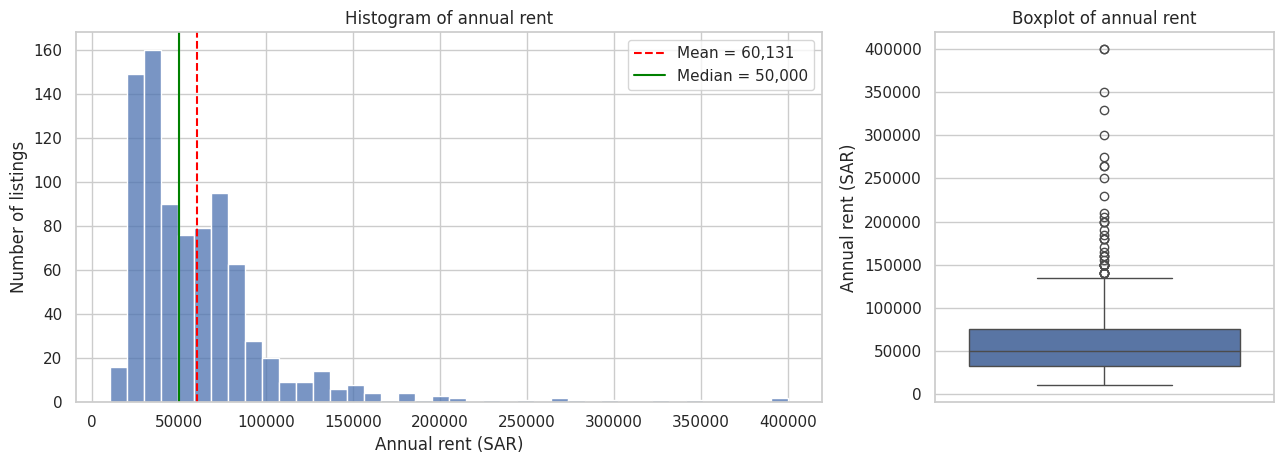

mean=60,131 median=50,000 std=42,963 min=10,000 max=400,000 skew=3.20
{0.25: 33000, 0.75: 75000, 0.9: 100000, 0.99: 240800}


In [17]:
rent = df_clean["annual_rent_sar"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [2.2, 1]})
sns.histplot(rent, bins=40, color="#4C72B0", ax=axes[0])
axes[0].axvline(rent.mean(), color="red", ls="--", label=f"Mean = {rent.mean():,.0f}")
axes[0].axvline(rent.median(), color="green", ls="-", label=f"Median = {rent.median():,.0f}")
axes[0].set_title("Histogram of annual rent")
axes[0].set_xlabel("Annual rent (SAR)"); axes[0].set_ylabel("Number of listings")
axes[0].legend()
sns.boxplot(y=rent, color="#4C72B0", ax=axes[1])
axes[1].set_title("Boxplot of annual rent"); axes[1].set_ylabel("Annual rent (SAR)")
plt.tight_layout()
plt.savefig("figures/fig1_rent_distribution.png", dpi=150)
plt.show()
q = rent.quantile([0.25, 0.75, 0.9, 0.99]).to_dict()
print(f"mean={rent.mean():,.0f} median={rent.median():,.0f} std={rent.std():,.0f} min={rent.min():,.0f} max={rent.max():,.0f} skew={rent.skew():.2f}")
print({k: round(v) for k, v in q.items()})

**Insight (Figure 1).** Annual rent is strongly right-skewed: the **median is 50,000 SAR** and the **mean is 60,131 SAR** (about 20% higher); the standard deviation is 42,963 SAR and the skewness is 3.20. Half of the listings are between 33,000 and 75,000 SAR; the 90th percentile is 100,000 SAR, the 99th is about 240,800 SAR and the maximum is 400,000 SAR. The minimum is 10,000 SAR because of the cut-off in step 3.3. Because of the skew, the **median describes a typical rent better than the mean**. This histogram mixes apartments, floors and villas, so part of the long right tail comes from villas; Within their own property type, 32 listings (3.8%) are flagged as high-rent outliers (22 apartments, 2 floors, 8 villas).

#### Figure 2 — Distribution of ln(annual rent)

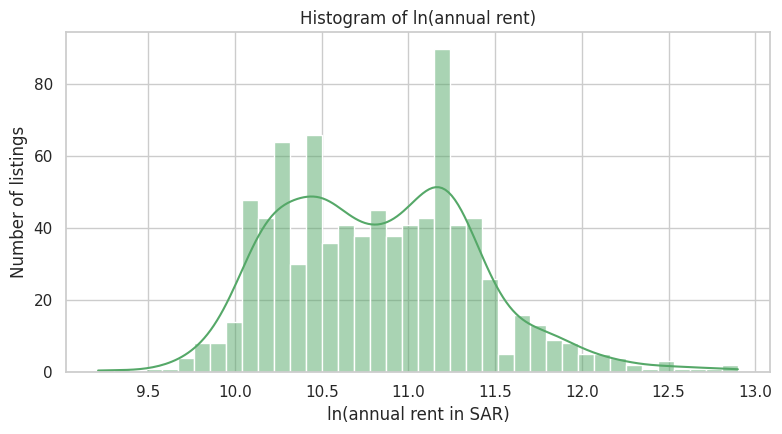

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_clean["log_annual_rent"], bins=40, kde=True, color="#55A868", ax=ax)
ax.set_title("Histogram of ln(annual rent)")
ax.set_xlabel("ln(annual rent in SAR)"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig2_log_rent_distribution.png", dpi=150)
plt.show()

**Insight (Figure 2).** After the log transformation the skewness drops from 3.20 to about 0.44, so the shape is much closer to symmetric all reported averages stay in SAR.

#### Figure 3 — Number of listings by property type

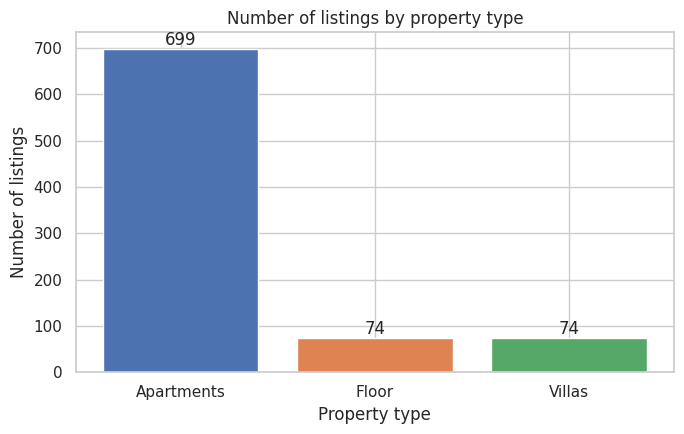

{'Apartments': 82.5, 'Floor': 8.7, 'Villas': 8.7}


In [19]:
type_counts = df_clean["property_type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(type_counts.index, type_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.bar_label(bars)
ax.set_title("Number of listings by property type")
ax.set_xlabel("Property type"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig3_listings_by_property_type.png", dpi=150)
plt.show()
print((df_clean["property_type"].value_counts(normalize=True) * 100).round(1).to_dict())

**Insight (Figure 3).** The sample has **699 apartments (82.5%)**, 74 floors (8.7%) and 74 villas (8.7%). Apartments dominate, but floors and villas each have 74 listings, so all three types have enough listings to be described. The primary data also has compounds, duplexes and studios, which have no counterpart in this dataset.

#### Figure 4 — Distribution of property area (up to 1,000 m²)

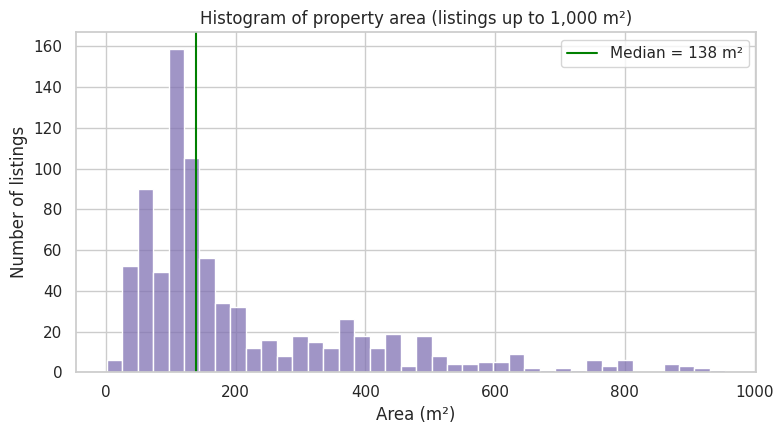

Listings not shown (area above 1,000 m2): 21
Median area by type: {'Apartments': 121.0, 'Floor': 306.0, 'Villas': 334.0}


In [20]:
area_plot = df_clean.loc[df_clean["area_sqm"] <= 1000, "area_sqm"]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(area_plot, bins=40, color="#8172B3", ax=ax)
ax.axvline(df_clean["area_sqm"].median(), color="green", label=f"Median = {df_clean['area_sqm'].median():,.0f} m²")
ax.set_title("Histogram of property area (listings up to 1,000 m²)")
ax.set_xlabel("Area (m²)"); ax.set_ylabel("Number of listings")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig4_area_distribution.png", dpi=150)
plt.show()
print("Listings not shown (area above 1,000 m2):", int(df_clean["area_flag"].sum()))
print("Median area by type:", df_clean.groupby("property_type")["area_sqm"].median().round(0).to_dict())

**Insight (Figure 4).** The **median area is 138 m²** and half of the listings are between 100 and 300 m². The distribution is right-skewed. The chart shows listings up to 1,000 m² to keep it readable; **21 listings above 1,000 m²** (the largest is 50,000 m², a villa) are not shown and are flagged in `area_flag`, because such values are probably land or plot size entered by the advertiser. The three property types differ clearly in size (median 121 m² for apartments, 306 m² for floors and 334 m² for villas)

#### Figure 5 — Number of listings by bedrooms

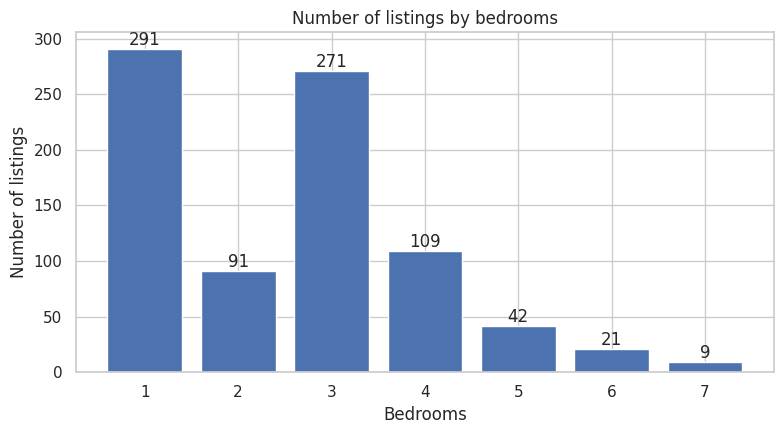

Missing: 13
{np.int64(1): 34.4, np.int64(2): 10.7, np.int64(3): 32.0, np.int64(4): 12.9, np.int64(5): 5.0, np.int64(6): 2.5, np.int64(7): 1.1}


In [21]:
bed_counts = df_clean["bedrooms"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bed_counts.index.astype(str), bed_counts.values, color="#4C72B0")
ax.bar_label(bars)
ax.set_title("Number of listings by bedrooms")
ax.set_xlabel("Bedrooms"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig5_listings_by_bedrooms.png", dpi=150)
plt.show()
print("Missing:", int(df_clean["bedrooms"].isna().sum()))
print((df_clean["bedrooms"].value_counts().sort_index() / len(df_clean) * 100).round(1).to_dict())

**Insight (Figure 5).** **One-bedroom (291 listings, 34.4%) and three-bedroom (271, 32.0%) listings are the most common**, followed by four (109, 12.9%) and two bedrooms (91, 10.7%). Listings with five or more bedrooms are rare (72 listings, 8.5%), and the bedroom count is missing for 13 listings (1.5%).

#### Figure 6 — Number of listings by bathrooms

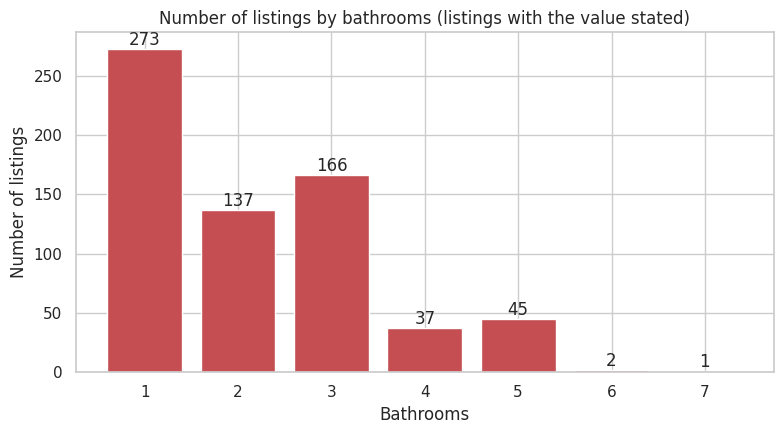

Stated: 661 | missing: 186
{np.int64(1): 41.3, np.int64(2): 20.7, np.int64(3): 25.1, np.int64(4): 5.6, np.int64(5): 6.8, np.int64(6): 0.3, np.int64(7): 0.2}


In [22]:
bath_counts = df_clean["bathrooms"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bath_counts.index.astype(str), bath_counts.values, color="#C44E52")
ax.bar_label(bars)
ax.set_title("Number of listings by bathrooms (listings with the value stated)")
ax.set_xlabel("Bathrooms"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig6_listings_by_bathrooms.png", dpi=150)
plt.show()
stated = df_clean["bathrooms"].notna().sum()
print("Stated:", int(stated), "| missing:", int(df_clean["bathrooms"].isna().sum()))
print((df_clean["bathrooms"].value_counts().sort_index() / stated * 100).round(1).to_dict())

**Insight (Figure 6).** Bathrooms are stated for 661 listings; **186 listings (22.0%) do not state them**, so the chart describes only the listings with the value. Among them, **one bathroom is the most common (273 listings, 41.3%)**, followed by three (166, 25.1%) and two (137, 20.7%); four, five or more bathrooms are less common.

#### Figure 7 — Number of listings in the 15 most frequent neighborhoods

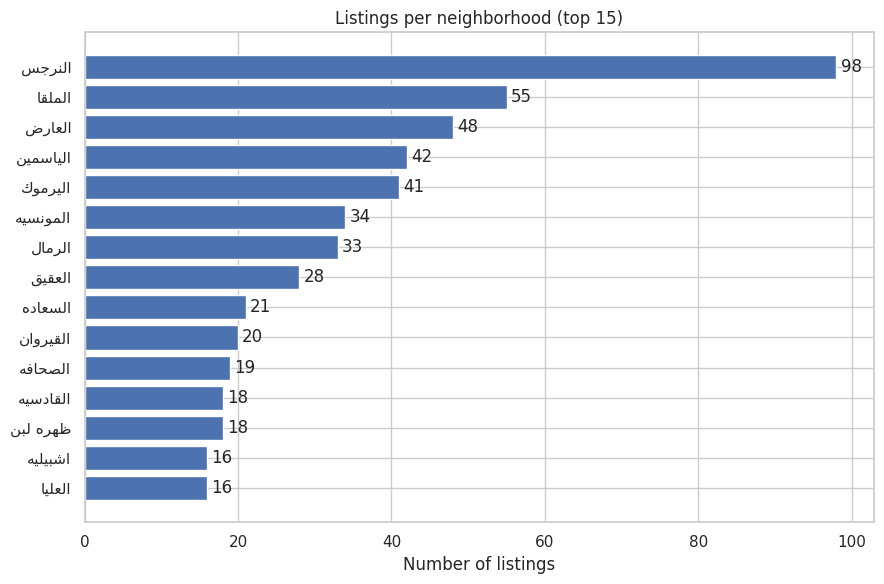

In [23]:
top15 = df_clean["neighborhood_ar"].value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh([ar(n) for n in top15.index], top15.values, color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Listings per neighborhood (top 15)")
ax.set_xlabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig7_top15_neighborhoods.png", dpi=150)
plt.show()

**Insight (Figure 7).** The 847 listings are spread over 95 neighborhoods, but unevenly: **Al Narjis (98), Al Malqa (55), Al Aridh (48), Al Yasmin (42) and Al Yarmuk (41)** hold 33.5% of all listings, while **55 of the 95 neighborhoods have fewer than 5 listings**.